# Dataset 1 — AirPassengers (≤200 pontos)

## Projeto de Deep Learning para Dados Tabulares e Séries Temporais

**Dataset:** Número mensal de passageiros aéreos internacionais (Jan/1949 – Dez/1960). **144 observações.**

| Divisão   | % |
|-----------|---|
| Treino    | 50% |
| Validação | 25% |
| Teste     | 25% |

**Cenário:** Previsão one-step-ahead
**Métricas:** MSE (Mean Squared Error) e MAPE (Mean Absolute Percentage Error)


## 1. Bibliotecas e Funções Auxiliares

In [ ]:
import os, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Bibliotecas carregadas!")

Bibliotecas carregadas!


In [ ]:
DATASETS_DIR = os.path.join(os.getcwd(), 'datasets')

def testar_estacionariedade(serie, nome="Série", sig=0.05):
    result = adfuller(serie.dropna())
    p = result[1]
    print(f"  ADF [{nome}] — estatística: {result[0]:.4f} | p-valor: {p:.4f} | {'Estacionária ✓' if p <= sig else 'NÃO estacionária ✗'}")
    return p <= sig

def determinar_d(serie, sig=0.05):
    s = serie.copy().dropna()
    d = 0
    print("Determinando parâmetro d:")
    while not testar_estacionariedade(s, f"d={d}", sig):
        s = s.diff().dropna()
        d += 1
        if d > 3:
            break
    print(f"  → d = {d}")
    return d

def criar_janelas(arr, janela):
    X, y = [], []
    for i in range(len(arr) - janela):
        X.append(arr[i:i+janela])
        y.append(arr[i+janela])
    return np.array(X), np.array(y)

def metricas(y_true, y_pred, label=""):
    mse  = mean_squared_error(np.array(y_true).flatten(), np.array(y_pred).flatten())
    mape = mean_absolute_percentage_error(np.array(y_true).flatten(), np.array(y_pred).flatten())
    if label:
        print(f"  {label}:  MSE={mse:.6f}  MAPE={mape:.4%}")
    return mse, mape

print("Funções auxiliares definidas!")

Funções auxiliares definidas!


## 2. Carregamento e Análise Exploratória

In [ ]:
df = pd.read_csv(os.path.join(DATASETS_DIR, 'AirPassengers.csv'))
df['time'] = pd.to_datetime(df['time'], format='%Y-%m')
df = df.set_index('time')
serie = df['target'].astype(float)
# Log-transformação: estabiliza variância multiplicativa
serie = np.log(serie)
print("Log-transformação aplicada.")
print(f"Tamanho: {len(serie)} obs | {serie.index[0]} → {serie.index[-1]}")
print(serie.describe())

Log-transformação aplicada.
Tamanho: 144 obs | 1949-01-01 00:00:00 → 1960-12-01 00:00:00
count    144.000000
mean       5.542176
std        0.441456
min        4.644391
25%        5.192957
50%        5.581599
75%        5.887489
max        6.432940
Name: target, dtype: float64


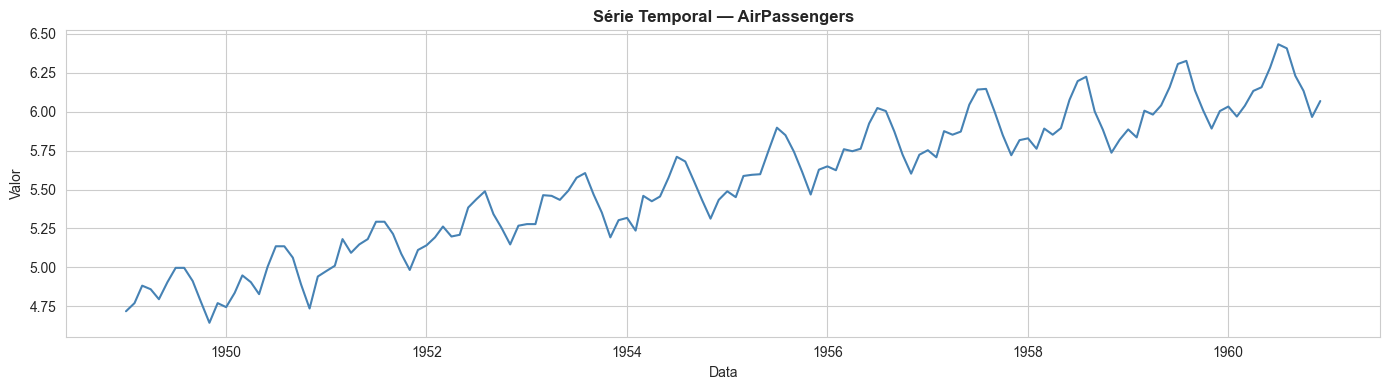

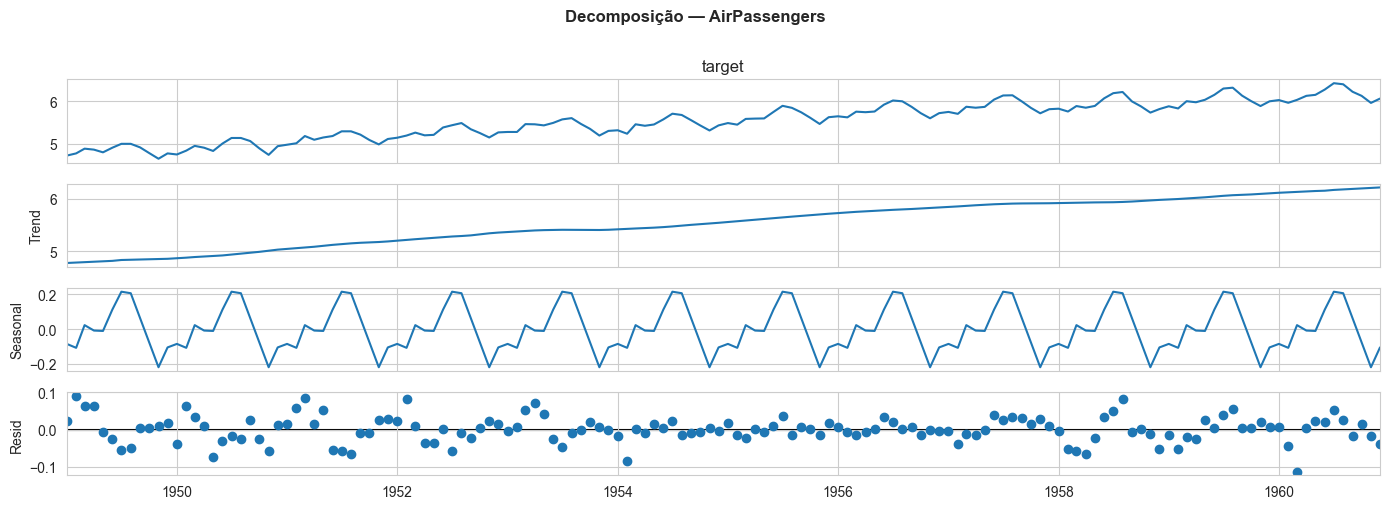

In [ ]:
# Visualização da série completa
plt.figure(figsize=(14, 4))
plt.plot(serie, color='steelblue')
plt.title('Série Temporal — AirPassengers', fontweight='bold')
plt.xlabel('Data'); plt.ylabel('Valor')
plt.tight_layout(); plt.show()

# Decomposição
decomp = seasonal_decompose(serie.dropna(), model='additive', period=12, extrapolate_trend='freq')
fig = decomp.plot()
fig.suptitle('Decomposição — AirPassengers', y=1.01, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Divisão Treino / Validação / Teste (50% / 25% / 25%)

Total: 144 | Treino: 72 | Validação: 36 | Teste: 36


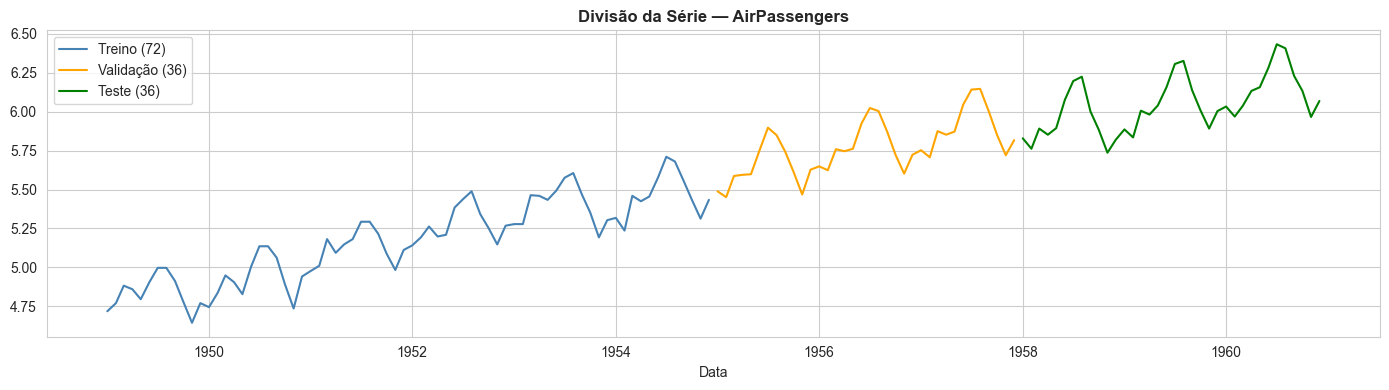

In [ ]:
n = len(serie)
train_size = int(n * 0.50)
val_size   = int(n * 0.25)

train = serie.iloc[:train_size]
val   = serie.iloc[train_size:train_size + val_size]
test  = serie.iloc[train_size + val_size:]

print(f"Total: {n} | Treino: {len(train)} | Validação: {len(val)} | Teste: {len(test)}")

plt.figure(figsize=(14, 4))
plt.plot(train, label=f'Treino ({len(train)})',     color='steelblue')
plt.plot(val,   label=f'Validação ({len(val)})',    color='orange')
plt.plot(test,  label=f'Teste ({len(test)})',       color='green')
plt.title('Divisão da Série — AirPassengers', fontweight='bold')
plt.xlabel('Data'); plt.legend(); plt.tight_layout(); plt.show()

## 4. Normalização (MinMaxScaler [0.1, 0.9])

In [ ]:
scaler = MinMaxScaler(feature_range=(0.1, 0.9))
train_sc = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
val_sc   = scaler.transform(val.values.reshape(-1, 1)).flatten()
test_sc  = scaler.transform(test.values.reshape(-1, 1)).flatten()

train_s = pd.Series(train_sc, index=train.index)
val_s   = pd.Series(val_sc,   index=val.index)
test_s  = pd.Series(test_sc,  index=test.index)

print(f"Treino normalizado — min: {train_sc.min():.3f} | max: {train_sc.max():.3f}")

Treino normalizado — min: 0.100 | max: 0.900


---
## 5. Modelo 1 — ARIMA (Metodologia Box & Jenkins)

### 5.1 Teste de Estacionariedade — Parâmetro d

In [ ]:
d = determinar_d(train_s)

Determinando parâmetro d:
  ADF [d=0] — estatística: -1.5404 | p-valor: 0.5134 | NÃO estacionária ✗
  ADF [d=1] — estatística: -2.1678 | p-valor: 0.2181 | NÃO estacionária ✗
  ADF [d=2] — estatística: -8.7514 | p-valor: 0.0000 | Estacionária ✓
  → d = 2


### 5.2 Análise ACF e PACF — Parâmetros p e q

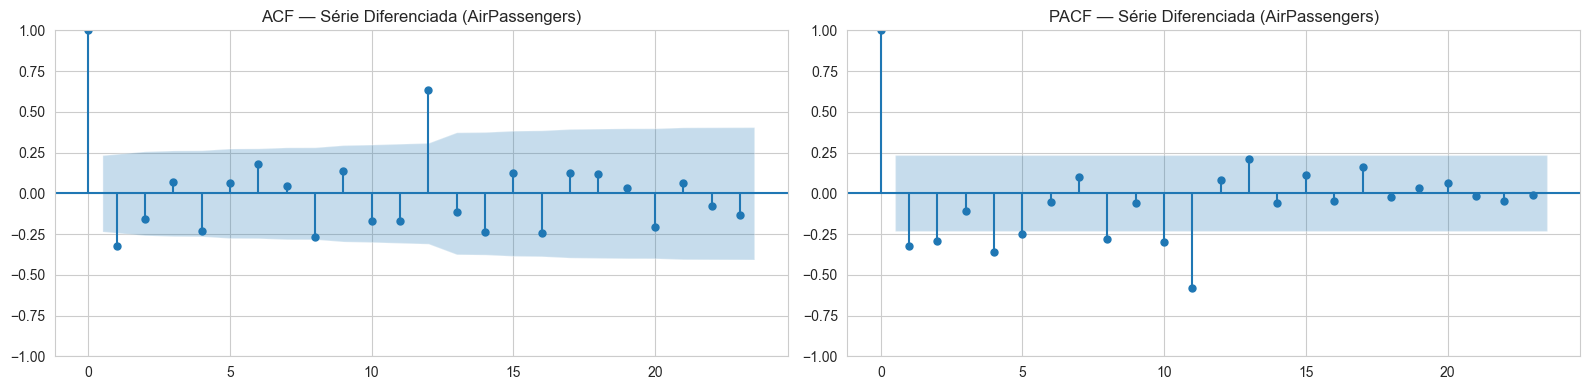

In [ ]:
serie_diff = train_s.copy()
for _ in range(d):
    serie_diff = serie_diff.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf( serie_diff, lags=min(30, len(serie_diff)//3), ax=axes[0])
axes[0].set_title('ACF — Série Diferenciada (AirPassengers)')
plot_pacf(serie_diff, lags=min(30, len(serie_diff)//3), ax=axes[1])
axes[1].set_title('PACF — Série Diferenciada (AirPassengers)')
plt.tight_layout(); plt.show()

### 5.3 Grid Search — Seleção por AIC

In [ ]:
resultados = []
for p, q in itertools.product(range(4), range(4)):
    try:
        m = ARIMA(train_s, order=(p, d, q)).fit()
        resultados.append({'p': p, 'd': d, 'q': q, 'AIC': round(m.aic, 2), 'BIC': round(m.bic, 2)})
    except Exception:
        pass

df_aic = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
print("Top 5 modelos ARIMA por AIC:")
print(df_aic.head(5).to_string(index=False))

best_order = tuple(df_aic.iloc[0][['p', 'd', 'q']].astype(int).values)
print(f"\nMelhor ordem selecionada: ARIMA{best_order}")

Top 5 modelos ARIMA por AIC:
 p  d  q     AIC     BIC
 0  2  3 -152.96 -143.96
 2  2  3 -152.23 -138.74
 0  2  1 -150.94 -146.45
 0  2  2 -150.86 -144.11
 1  2  2 -150.86 -141.87

Melhor ordem selecionada: ARIMA(np.int64(0), np.int64(2), np.int64(3))


### 5.4 Ajuste do Melhor Modelo e Análise dos Resíduos

In [ ]:
arima_fit = ARIMA(train_s, order=best_order).fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   72
Model:                 ARIMA(0, 2, 3)   Log Likelihood                  80.478
Date:                Sat, 07 Mar 2026   AIC                           -152.955
Time:                        11:07:05   BIC                           -143.961
Sample:                    01-01-1949   HQIC                          -149.383
                         - 12-01-1954                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.1931      0.524     -2.276      0.023      -2.220      -0.166
ma.L2         -0.4810      0.178     -2.698      0.007      -0.831      -0.132
ma.L3          0.6761      0.377      1.793      0.0

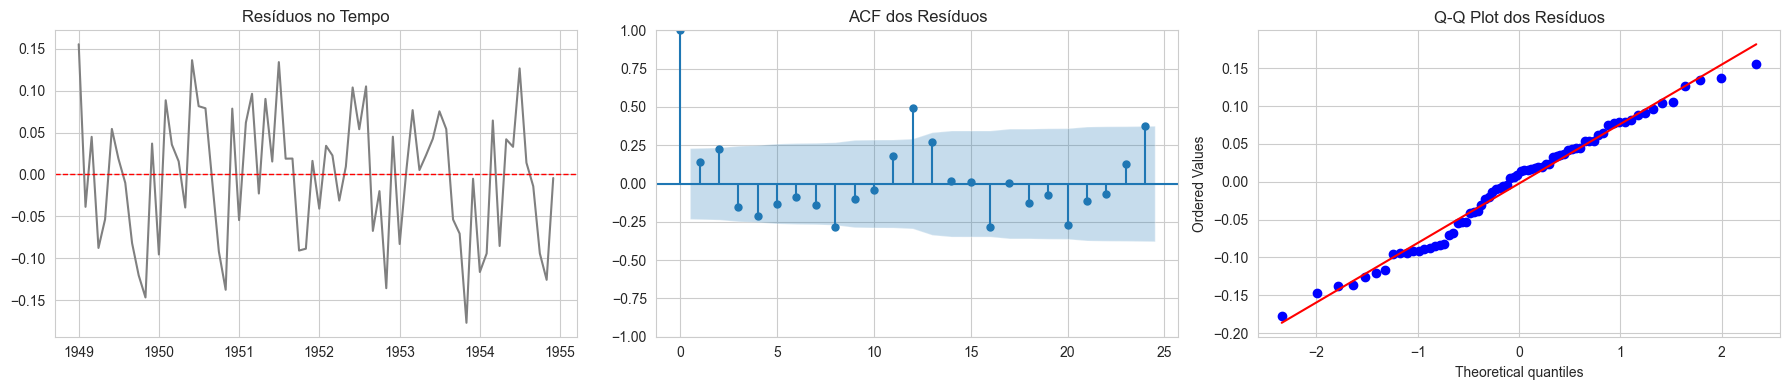

Ljung-Box (p > 0.05 → ruído branco):
      lb_stat  lb_pvalue
1    1.541011   0.214467
2    5.317715   0.070028
3    7.068913   0.069733
4   10.505521   0.032721
5   11.875054   0.036541
6   12.515216   0.051414
7   14.092651   0.049558
8   20.788155   0.007732
9   21.662985   0.010011
10  21.824991   0.016021


In [ ]:
residuos = arima_fit.resid.dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(residuos, color='gray')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Resíduos no Tempo')

plot_acf(residuos, lags=min(24, len(residuos)//3), ax=axes[1])
axes[1].set_title('ACF dos Resíduos')

stats.probplot(residuos, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot dos Resíduos')

plt.tight_layout(); plt.show()

# Teste Ljung-Box
lb = acorr_ljungbox(residuos, lags=10, return_df=True)
print("Ljung-Box (p > 0.05 → ruído branco):")
print(lb[['lb_stat', 'lb_pvalue']].to_string())

### 5.5 Previsão One-Step-Ahead

In [ ]:
# Fitted values no treino (offline)
arima_pred_train = arima_fit.fittedvalues.dropna()
train_aligned    = train_s.loc[arima_pred_train.index]

# Previsão online no teste (expanding window — um passo de cada vez)
print("Gerando previsões one-step-ahead no teste...")
history = list(train_s.values)
arima_pred_test = []
for t in range(len(test_s)):
    m    = ARIMA(history, order=best_order).fit()
    pred = float(np.array(m.forecast(steps=1)).flat[0])
    arima_pred_test.append(pred)
    history.append(float(test_s.iloc[t]))
arima_pred_test = np.array(arima_pred_test)
print(f"Concluído: {len(arima_pred_test)} previsões geradas.")

Gerando previsões one-step-ahead no teste...
Concluído: 36 previsões geradas.


### 5.6 Métricas e Gráficos

Métricas ARIMA
  Treino:  MSE=0.005935  MAPE=18.1963%
  Teste:  MSE=0.010160  MAPE=7.6357%


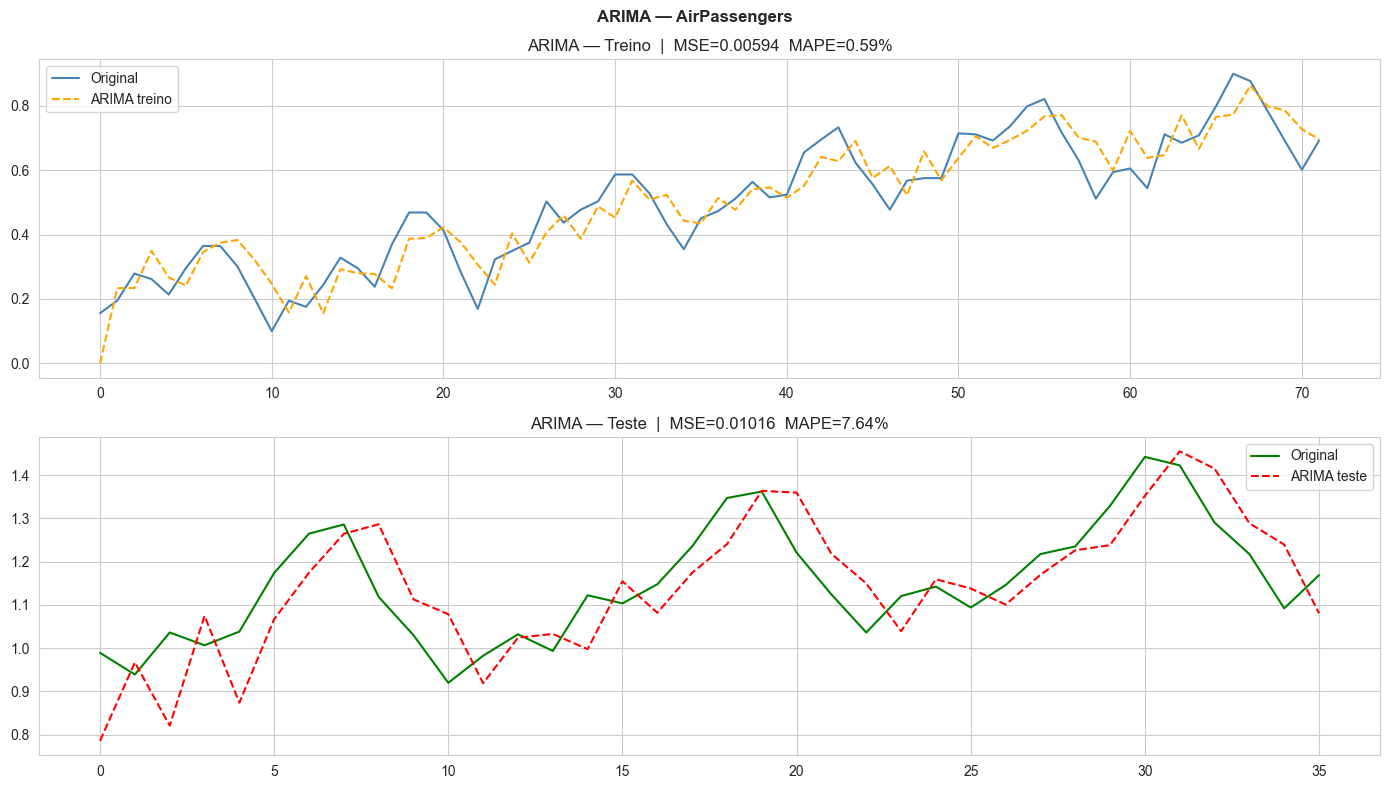

In [ ]:
print("="*50)
print("Métricas ARIMA")
print("="*50)
mse_ar_tr,  mape_ar_tr  = metricas(train_aligned, arima_pred_train, "Treino")
mse_ar_te,  mape_ar_te  = metricas(test_s,         arima_pred_test,  "Teste")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(train_aligned.values, label='Original',       color='steelblue')
axes[0].plot(arima_pred_train.values, label='ARIMA treino', color='orange', linestyle='--')
axes[0].set_title(f'ARIMA — Treino  |  MSE={mse_ar_tr:.5f}  MAPE={mse_ar_tr:.2%}')
axes[0].legend()

axes[1].plot(test_s.values, label='Original',      color='green')
axes[1].plot(arima_pred_test, label='ARIMA teste', color='red', linestyle='--')
axes[1].set_title(f'ARIMA — Teste  |  MSE={mse_ar_te:.5f}  MAPE={mape_ar_te:.2%}')
axes[1].legend()

plt.suptitle('ARIMA — AirPassengers', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. Modelo 2 — MLP (Multilayer Perceptron)

### 6.1 Janelamento Deslizante

In [ ]:
WINDOW = 12   # janela = período sazonal

all_data = np.concatenate([train_sc, val_sc, test_sc])
X_all, y_all = criar_janelas(all_data, WINDOW)

n_tr = len(train_sc) - WINDOW
n_va = len(val_sc)
n_te = len(test_sc)

X_tr, y_tr = X_all[:n_tr],          y_all[:n_tr]
X_va, y_va = X_all[n_tr:n_tr+n_va], y_all[n_tr:n_tr+n_va]
X_te, y_te = X_all[n_tr+n_va:],     y_all[n_tr+n_va:]

print(f"Janela: {WINDOW} | X_treino: {X_tr.shape} | X_val: {X_va.shape} | X_teste: {X_te.shape}")

Janela: 12 | X_treino: (60, 12) | X_val: (36, 12) | X_teste: (36, 12)


### 6.2 Random Search (seleção pelo conjunto de validação)

In [ ]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
}

best_mlp      = None
best_mse_val  = np.inf
resultados_mlp = []

for hidden in param_grid['hidden_layer_sizes']:
    for activation in param_grid['activation']:
        for lr in param_grid['learning_rate_init']:
            mses = []
            for seed in [42, 7, 13]:
                mlp = MLPRegressor(
                    hidden_layer_sizes=hidden, activation=activation,
                    learning_rate_init=lr, max_iter=500, random_state=seed
                )
                mlp.fit(X_tr, y_tr)
                mses.append(mean_squared_error(y_va, mlp.predict(X_va)))
            mse_mean = np.mean(mses)
            resultados_mlp.append({'hidden': str(hidden), 'activation': activation,
                                   'lr': lr, 'MSE_val': round(mse_mean, 6)})
            if mse_mean < best_mse_val:
                best_mse_val = mse_mean
                best_mlp = mlp   # último seed treinado, mas config vencedora

df_mlp = pd.DataFrame(resultados_mlp).sort_values('MSE_val').reset_index(drop=True)
print("Top 5 configurações MLP:")
print(df_mlp.head(5).to_string(index=False))
print(f"\nMelhor MLP: {best_mlp}")

Top 5 configurações MLP:
    hidden activation   lr  MSE_val
(100, 100)       relu 0.01 0.002351
 (100, 50)       relu 0.01 0.003112
    (100,)       relu 0.01 0.004676
(100, 100)       tanh 0.01 0.005712
  (50, 50)       relu 0.01 0.006303

Melhor MLP: MLPRegressor(hidden_layer_sizes=(100, 100), learning_rate_init=0.01,
             max_iter=500, random_state=13)


### 6.3 Avaliação do Melhor Modelo MLP

Métricas MLP
  Treino:  MSE=0.002598  MAPE=9.1526%
  Validação:  MSE=0.002117  MAPE=4.1739%
  Teste:  MSE=0.002273  MAPE=3.4702%


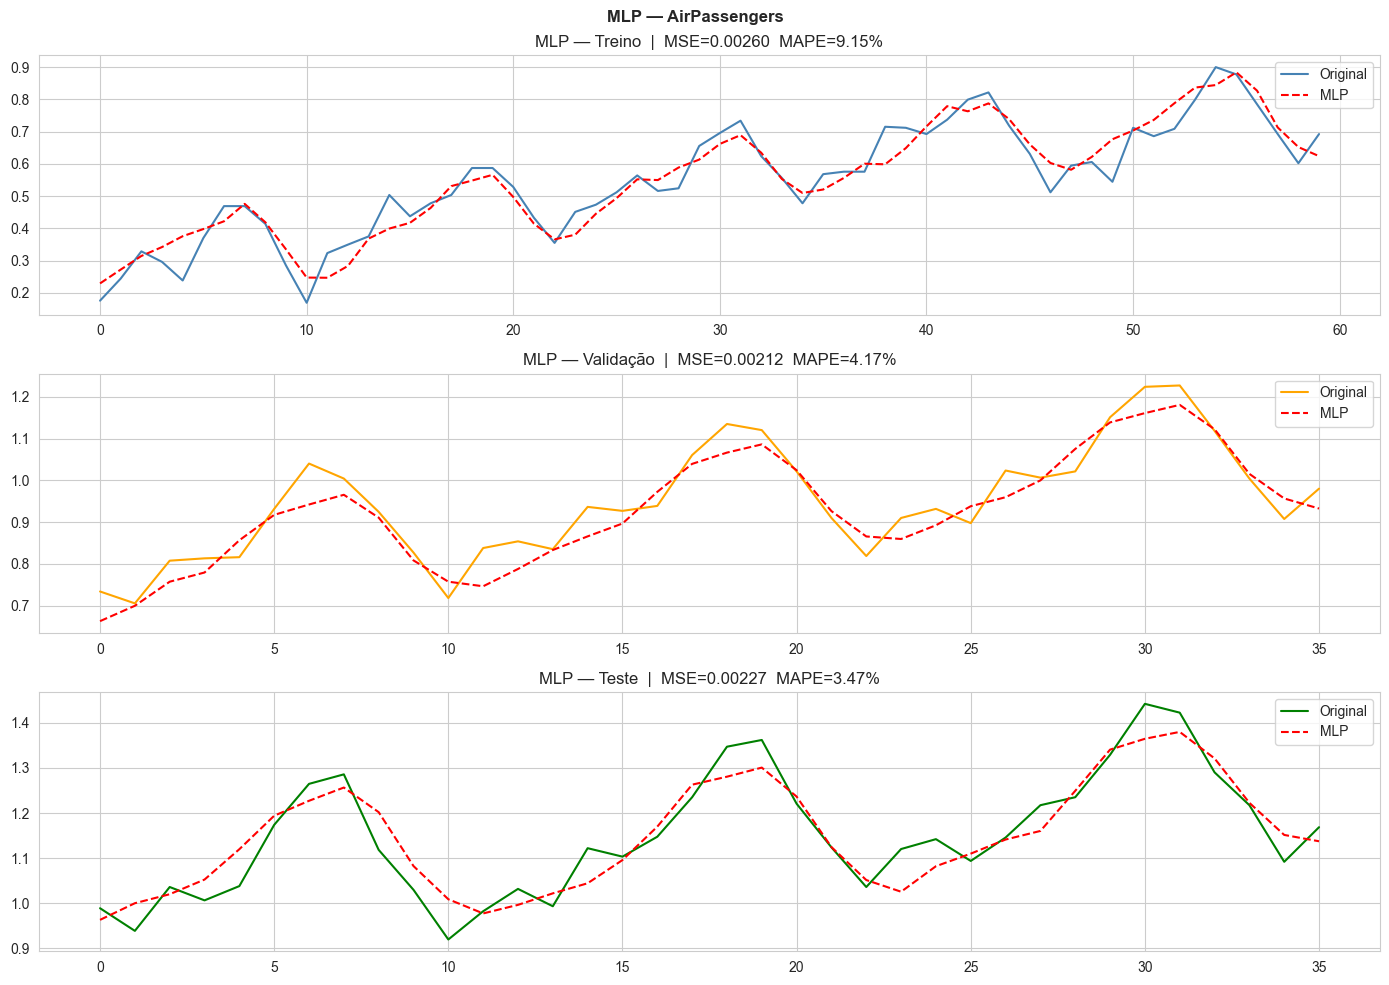

In [ ]:
mlp_pred_tr = best_mlp.predict(X_tr)
mlp_pred_va = best_mlp.predict(X_va)
mlp_pred_te = best_mlp.predict(X_te)

print("="*50)
print("Métricas MLP")
print("="*50)
mse_mlp_tr,  mape_mlp_tr  = metricas(y_tr, mlp_pred_tr, "Treino")
mse_mlp_va,  mape_mlp_va  = metricas(y_va, mlp_pred_va, "Validação")
mse_mlp_te,  mape_mlp_te  = metricas(y_te, mlp_pred_te, "Teste")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, y_t, y_p, lbl, mse, mape_v, col in [
    (axes[0], y_tr, mlp_pred_tr, 'Treino',    mse_mlp_tr, mape_mlp_tr, 'steelblue'),
    (axes[1], y_va, mlp_pred_va, 'Validação', mse_mlp_va, mape_mlp_va, 'orange'),
    (axes[2], y_te, mlp_pred_te, 'Teste',     mse_mlp_te, mape_mlp_te, 'green'),
]:
    ax.plot(y_t, label='Original', color=col)
    ax.plot(y_p, label='MLP',      color='red', linestyle='--')
    ax.set_title(f'MLP — {lbl}  |  MSE={mse:.5f}  MAPE={mape_v:.2%}')
    ax.legend()
plt.suptitle('MLP — AirPassengers', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 7. Modelo 3 — LSTM (Long Short-Term Memory)

### 7.1 Reshape dos Dados para LSTM [samples, timesteps, features]

In [ ]:
X_tr_l = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
X_va_l = X_va.reshape(X_va.shape[0], X_va.shape[1], 1)
X_te_l = X_te.reshape(X_te.shape[0], X_te.shape[1], 1)
print(f"X_treino LSTM: {X_tr_l.shape}")

X_treino LSTM: (60, 12, 1)


### 7.2 Busca de Hiperparâmetros LSTM

In [ ]:
configs_lstm = [
    {'units': 32,  'layers': 1, 'dropout': 0.1, 'batch': 16},
    {'units': 64,  'layers': 1, 'dropout': 0.2, 'batch': 16},
    {'units': 64,  'layers': 2, 'dropout': 0.2, 'batch': 32},
    {'units': 128, 'layers': 1, 'dropout': 0.2, 'batch': 16},
    {'units': 128, 'layers': 2, 'dropout': 0.3, 'batch': 32},
]

best_lstm      = None
best_mse_lstm  = np.inf
resultados_lstm = []

for cfg_l in configs_lstm:
    tf.random.set_seed(SEED)

    model = Sequential()
    return_seq = (cfg_l['layers'] > 1)
    model.add(LSTM(cfg_l['units'], return_sequences=return_seq, input_shape=(WINDOW, 1)))
    if cfg_l['layers'] > 1:
        model.add(LSTM(cfg_l['units'] // 2))
    model.add(Dropout(cfg_l['dropout']))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    model.fit(X_tr_l, y_tr,
              validation_data=(X_va_l, y_va),
              epochs=100, batch_size=cfg_l['batch'],
              callbacks=[es], verbose=0)

    val_pred = model.predict(X_va_l, verbose=0).flatten()
    mse_v    = mean_squared_error(y_va, val_pred)
    resultados_lstm.append({**cfg_l, 'MSE_val': round(mse_v, 6)})
    print(f"units={cfg_l['units']} layers={cfg_l['layers']} dropout={cfg_l['dropout']} | Val MSE={mse_v:.5f}")

    if mse_v < best_mse_lstm:
        best_mse_lstm = mse_v
        best_lstm = model

df_lstm = pd.DataFrame(resultados_lstm).sort_values('MSE_val').reset_index(drop=True)
print("\nResultados LSTM:")
print(df_lstm.to_string(index=False))
print(f"\nMelhor LSTM — Val MSE: {best_mse_lstm:.5f}")

units=32 layers=1 dropout=0.1 | Val MSE=0.01260
units=64 layers=1 dropout=0.2 | Val MSE=0.01241
units=64 layers=2 dropout=0.2 | Val MSE=0.01385
units=128 layers=1 dropout=0.2 | Val MSE=0.01334
units=128 layers=2 dropout=0.3 | Val MSE=0.01272

Resultados LSTM:
 units  layers  dropout  batch  MSE_val
    64       1      0.2     16 0.012415
    32       1      0.1     16 0.012604
   128       2      0.3     32 0.012717
   128       1      0.2     16 0.013342
    64       2      0.2     32 0.013847

Melhor LSTM — Val MSE: 0.01241


### 7.3 Avaliação do Melhor Modelo LSTM

Métricas LSTM
  Treino:  MSE=0.010500  MAPE=19.2559%
  Validação:  MSE=0.012415  MAPE=9.4772%
  Teste:  MSE=0.016079  MAPE=8.3234%


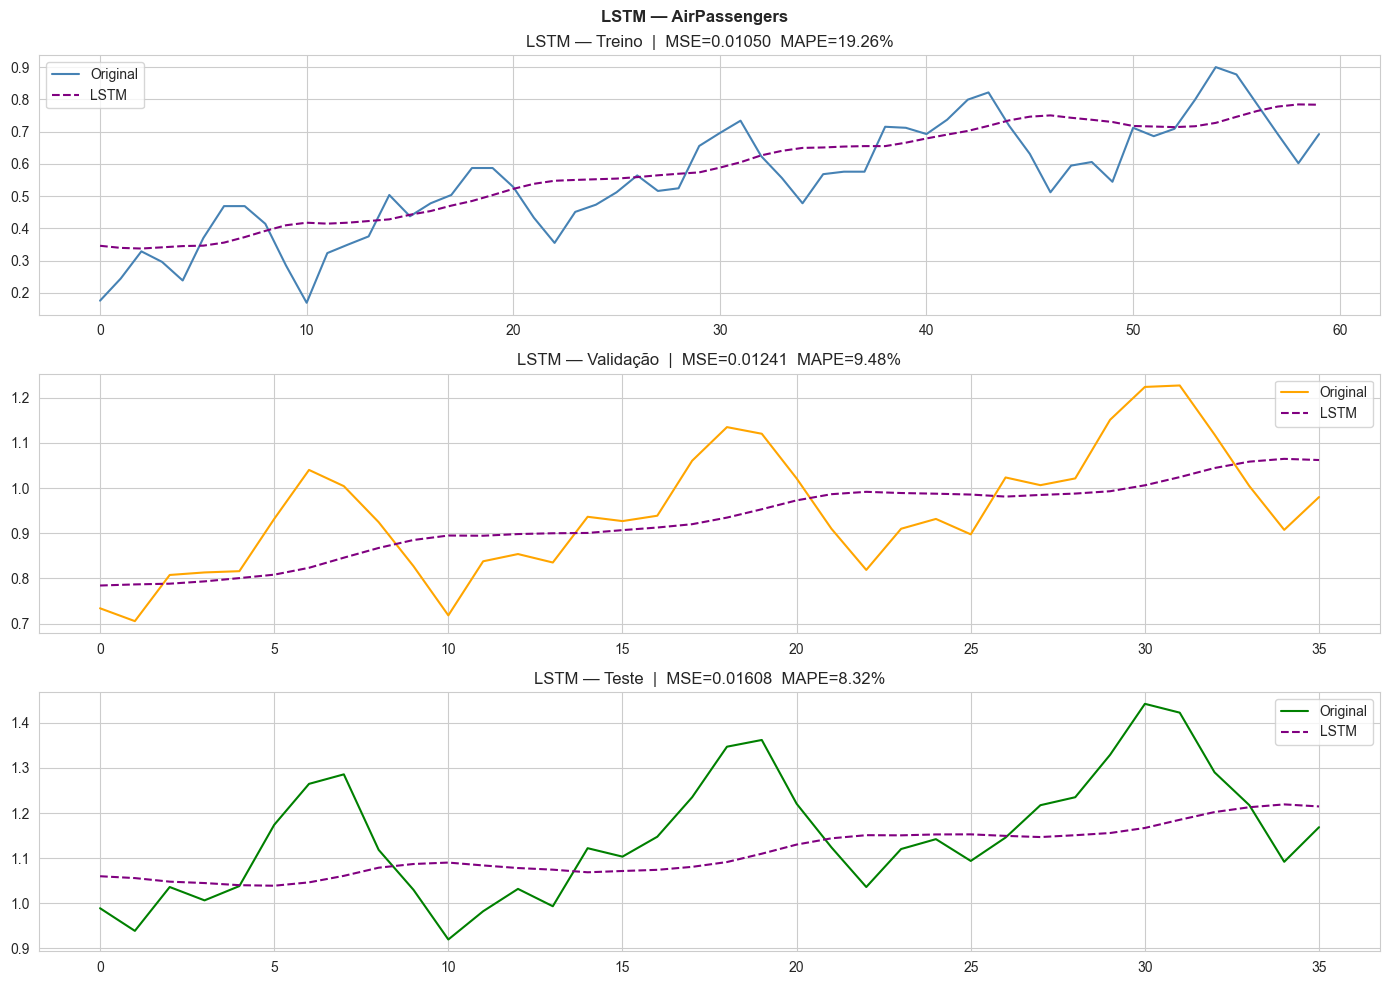

In [ ]:
lstm_pred_tr = best_lstm.predict(X_tr_l, verbose=0).flatten()
lstm_pred_va = best_lstm.predict(X_va_l, verbose=0).flatten()
lstm_pred_te = best_lstm.predict(X_te_l, verbose=0).flatten()

print("="*50)
print("Métricas LSTM")
print("="*50)
mse_lstm_tr,  mape_lstm_tr  = metricas(y_tr, lstm_pred_tr, "Treino")
mse_lstm_va,  mape_lstm_va  = metricas(y_va, lstm_pred_va, "Validação")
mse_lstm_te,  mape_lstm_te  = metricas(y_te, lstm_pred_te, "Teste")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, y_t, y_p, lbl, mse, mape_v, col in [
    (axes[0], y_tr, lstm_pred_tr, 'Treino',    mse_lstm_tr, mape_lstm_tr, 'steelblue'),
    (axes[1], y_va, lstm_pred_va, 'Validação', mse_lstm_va, mape_lstm_va, 'orange'),
    (axes[2], y_te, lstm_pred_te, 'Teste',     mse_lstm_te, mape_lstm_te, 'green'),
]:
    ax.plot(y_t, label='Original', color=col)
    ax.plot(y_p, label='LSTM',     color='purple', linestyle='--')
    ax.set_title(f'LSTM — {lbl}  |  MSE={mse:.5f}  MAPE={mape_v:.2%}')
    ax.legend()
plt.suptitle('LSTM — AirPassengers', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 8. Comparação dos Modelos

In [ ]:
comparacao = pd.DataFrame({
    'Modelo':      ['ARIMA', 'MLP', 'LSTM'],
    'MSE Treino':  [mse_ar_tr,  mse_mlp_tr,  mse_lstm_tr],
    'MAPE Treino': [mape_ar_tr, mape_mlp_tr, mape_lstm_tr],
    'MSE Val':     ['-',        mse_mlp_va,  mse_lstm_va],
    'MAPE Val':    ['-',        mape_mlp_va, mape_lstm_va],
    'MSE Teste':   [mse_ar_te,  mse_mlp_te,  mse_lstm_te],
    'MAPE Teste':  [mape_ar_te, mape_mlp_te, mape_lstm_te],
})

print("="*70)
print(f"COMPARAÇÃO DOS MODELOS — AirPassengers")
print("="*70)
print(comparacao.to_string(index=False))
print("="*70)

# Identificar melhor por MSE no teste
mse_test_vals = [mse_ar_te, mse_mlp_te, mse_lstm_te]
melhor_idx    = np.argmin(mse_test_vals)
print(f"\nMelhor modelo (menor MSE no Teste): {['ARIMA', 'MLP', 'LSTM'][melhor_idx]}")

COMPARAÇÃO DOS MODELOS — AirPassengers
Modelo  MSE Treino  MAPE Treino   MSE Val  MAPE Val  MSE Teste  MAPE Teste
 ARIMA    0.005935     0.181963         -         -   0.010160    0.076357
   MLP    0.002598     0.091526  0.002117  0.041739   0.002273    0.034702
  LSTM    0.010500     0.192559  0.012415  0.094772   0.016079    0.083234

Melhor modelo (menor MSE no Teste): MLP


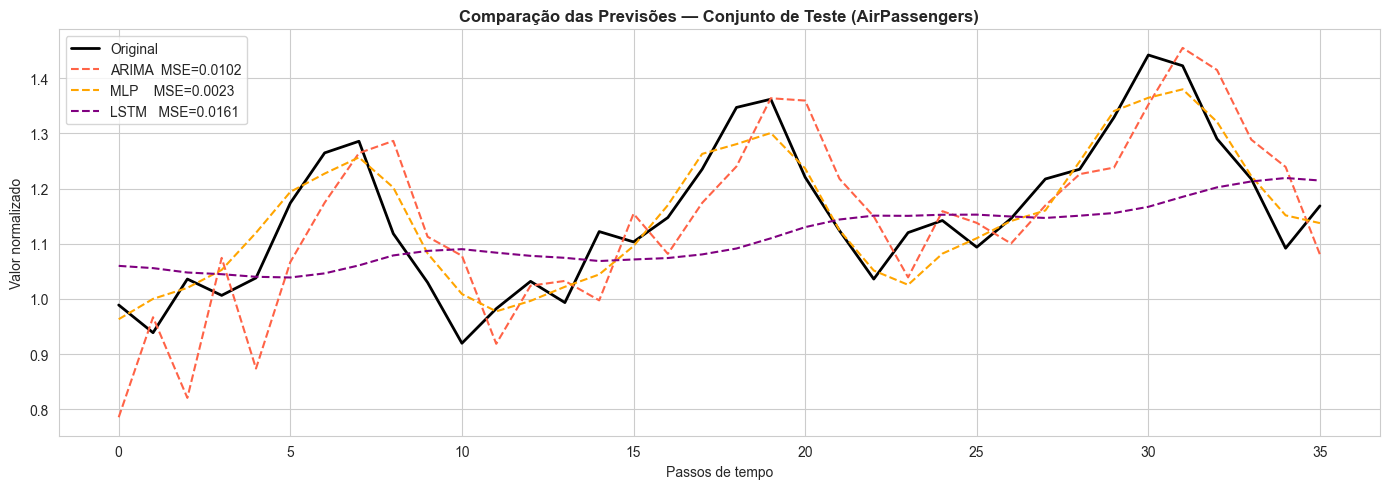

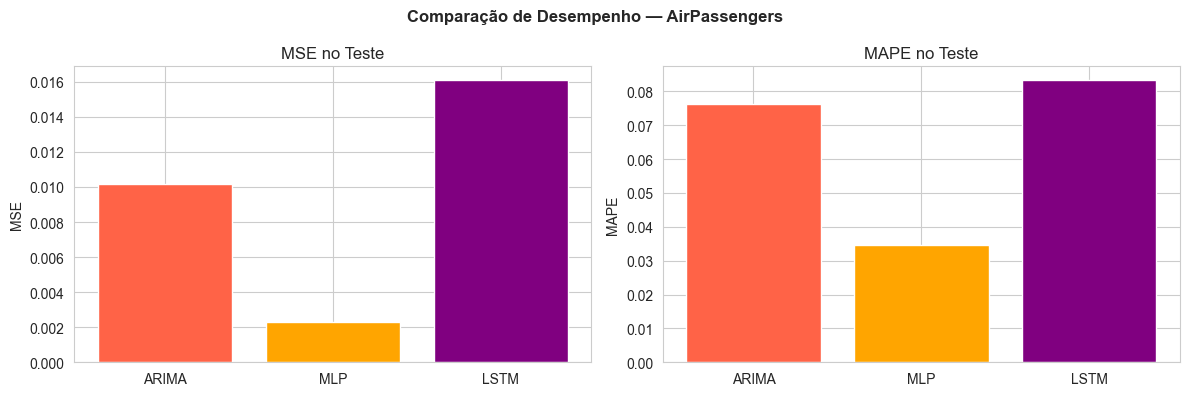

In [ ]:
# Gráfico comparativo no conjunto de TESTE
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_te,           label='Original',                     color='black',  linewidth=2)
ax.plot(arima_pred_test, label=f'ARIMA  MSE={mse_ar_te:.4f}',  linestyle='--', color='tomato')
ax.plot(mlp_pred_te,     label=f'MLP    MSE={mse_mlp_te:.4f}', linestyle='--', color='orange')
ax.plot(lstm_pred_te,    label=f'LSTM   MSE={mse_lstm_te:.4f}',linestyle='--', color='purple')
ax.set_title('Comparação das Previsões — Conjunto de Teste (AirPassengers)', fontweight='bold')
ax.set_xlabel('Passos de tempo'); ax.set_ylabel('Valor normalizado')
ax.legend(); plt.tight_layout(); plt.show()

# Barplot de MSE no teste
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
modelos = ['ARIMA', 'MLP', 'LSTM']
cores   = ['tomato', 'orange', 'purple']

axes[0].bar(modelos, [mse_ar_te,  mse_mlp_te,  mse_lstm_te],  color=cores)
axes[0].set_title('MSE no Teste'); axes[0].set_ylabel('MSE')

axes[1].bar(modelos, [mape_ar_te, mape_mlp_te, mape_lstm_te], color=cores)
axes[1].set_title('MAPE no Teste'); axes[1].set_ylabel('MAPE')

plt.suptitle('Comparação de Desempenho — AirPassengers', fontweight='bold')
plt.tight_layout(); plt.show()